<a href="https://www.kaggle.com/code/leandrocassius/evaluating-store-performance-with-bigquery?scriptVersionId=324695361" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Online Store Performance: Insights from Google Analytics Data using BigQuery

In this project, we will leverage the power of BigQuery, Google Cloud's fully-managed data warehouse, to extract valuable insights from vast amounts of data.

The ability to understand customer behavior, track conversions, and optimize the performance of an online store is crucial for businesses to thrive in the digital era. With Google Analytics providing a wealth of information about website visitors, traffic sources, and user interactions, we can uncover hidden patterns and extract actionable insights for stakeholders.

In this Kaggle notebook, I'll evaluate the performance of an online store using Google Analytics data. We aim to answer critical questions such as:

 * What are the main traffic sources driving visitors to the online store?
 * How do user demographics and behaviors impact conversion rates?
 * What are the most visited pages in the website?
 * Are there any seasonal or daily trends or patterns in website traffic and sales?
 * Can we identify any potential areas for improvement in the user experience or marketing strategies?

To answer these questions, we will use BigQuery, which allows us to handle large-scale datasets efficiently and perform complex queries seamlessly. By combining SQL queries, data visualization, and exploratory analysis techniques, we will gain valuable insights into the online store's performance and make data-driven recommendations for optimization.

# Checking the Database

First of all, let's have a look at the database and see how the information is stored.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
import pandas as pd 
import bq_helper

# Define theme and style for all seaborn charts
sns.set_theme(
    context='notebook',
    palette='Accent',
    style='darkgrid'
)

palette = sns.color_palette('Accent')

# Set database we want to query
PROJECT = "bigquery-public-data"
DATASET = "google_analytics_sample"

# Instantiate client
client = bq_helper.BigQueryHelper(
    active_project=PROJECT, 
    dataset_name=DATASET)

# Check first few rows
client.head("ga_sessions_20170101", num_rows=5)

Using Kaggle's public dataset BigQuery integration.


,visitorId,visitNumber,visitId,visitStartTime,date,totals,trafficSource,device,geoNetwork,customDimensions,hits,fullVisitorId,userId,channelGrouping,socialEngagementType
0,None,2,1483290878,1483290878,20170101,"{'visits': 1, 'hits': 2, 'pageviews': 1, 'time...","{'referralPath': None, 'campaign': '(not set)'...","{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Europe', 'subContinent': 'South...","[{'index': 4, 'value': 'EMEA'}]","[{'hitNumber': 1, 'time': 0, 'hour': 9, 'minut...",7431279462169656568,None,Organic Search,Not Socially Engaged
1,None,1,1483293597,1483293597,20170101,"{'visits': 1, 'hits': 2, 'pageviews': 2, 'time...",{'referralPath': '/YKEI_mrn/items/c10b14f9a69f...,"{'browser': 'Safari', 'browserVersion': 'not a...","{'continent': 'Asia', 'subContinent': 'Eastern...","[{'index': 4, 'value': 'APAC'}]","[{'hitNumber': 1, 'time': 0, 'hour': 9, 'minut...",1336484329946561874,None,Referral,Not Socially Engaged
2,None,1,1483292307,1483292307,20170101,"{'visits': 1, 'hits': 2, 'pageviews': 2, 'time...","{'referralPath': None, 'campaign': '(not set)'...","{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...","[{'index': 4, 'value': 'North America'}]","[{'hitNumber': 1, 'time': 0, 'hour': 9, 'minut...",1701623065972643878,None,Organic Search,Not Socially Engaged
3,None,1,1483299786,1483299786,20170101,"{'visits': 1, 'hits': 2, 'pageviews': 2, 'time...","{'referralPath': None, 'campaign': '(not set)'...","{'browser': 'Safari', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...","[{'index': 4, 'value': 'North America'}]","[{'hitNumber': 1, 'time': 0, 'hour': 11, 'minu...",398831489799928961,None,Organic Search,Not Socially Engaged
4,None,3,1483305691,1483305691,20170101,"{'visits': 1, 'hits': 2, 'pageviews': 2, 'time...","{'referralPath': None, 'campaign': '(not set)'...","{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...","[{'index': 4, 'value': 'North America'}]","[{'hitNumber': 1, 'time': 0, 'hour': 13, 'minu...",5139184322193043543,None,Display,Not Socially Engaged


# Data Description
First, let's have a look around the fields and try to understand better the parameters of the data.

In [2]:
# Set the source now, we will be working with the 
# same source throughout the notebook
source = "`bigquery-public-data.google_analytics_sample.ga_sessions_*`"

# Check the data in the ga sessions
query = f"""
    SELECT
        MIN(PARSE_DATE('%Y%m%d', _TABLE_SUFFIX)) AS start_date,
        MAX(PARSE_DATE('%Y%m%d', _TABLE_SUFFIX)) AS end_date,
        COUNT(DISTINCT _TABLE_SUFFIX) AS total_days,
        COUNT(*) AS total_sessions,
        COUNT(DISTINCT fullVisitorId) AS unique_visitors,
        COUNT(DISTINCT channelGrouping) AS channels,
        COUNT(DISTINCT geoNetwork.country) AS countries,
        ROUND(AVG(totals.pageviews), 2) AS avg_pageviews,
        COUNTIF(totals.transactions IS NOT NULL) AS total_transactions
    FROM {source}
"""

# Display
overview = client.query_to_pandas_safe(query)
overview.T.rename(columns={0: "value"})

,value
start_date,2016-08-01
end_date,2017-08-01
total_days,366
total_sessions,903653
unique_visitors,714167
channels,8
countries,222
avg_pageviews,3.85
total_transactions,11552


This basic information is very useful:

* We see that it covers 1 year, from July 2016 to July 2017;
* We get almost 1M sessions and over 10 thousand transactions;
* 222 countries overall;
* 8 unique channels.

This gives us a lot of data to work with, let's start by checking these main channels below:

# Main Channels

What were the main traffic chanels driving visitors to the online store [in July 2017]?

By checking the main traffic sources, we can find out more about the store's approach to marketing and how well or how bad some sources are performing. There is also a month-on-month detailed information for each source later in this project, when we try to identify growth trends.

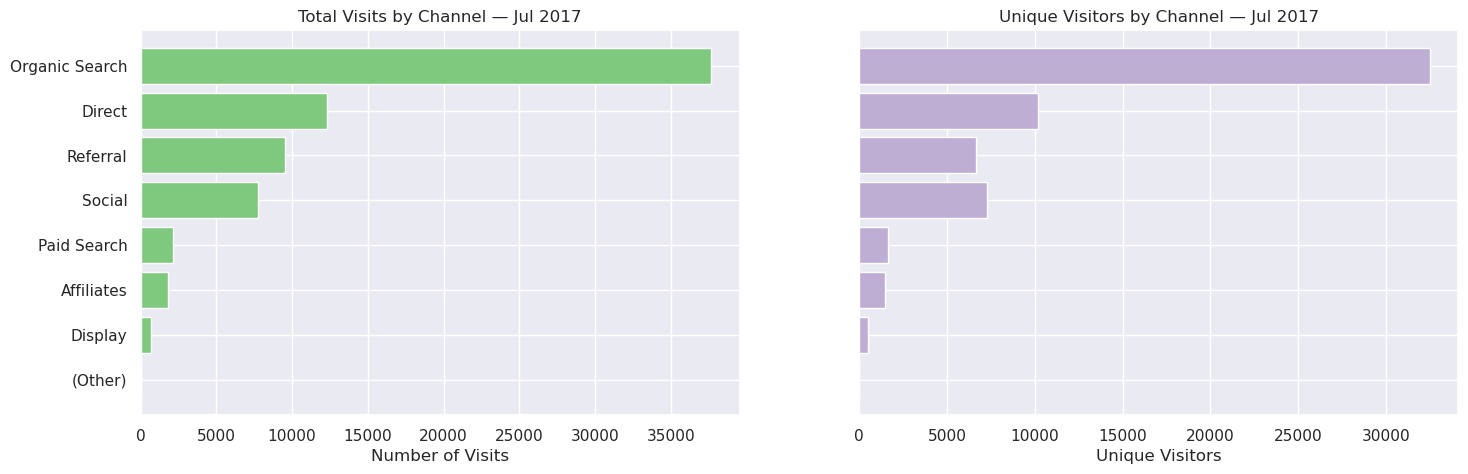

In [3]:
# Create query for July 2017
ts_query = f"""
    SELECT
        channelGrouping AS source,
        COUNT(*) AS number_of_visits,
        COUNT(DISTINCT fullVisitorId) AS unique_visitors
    FROM {source}
    WHERE _TABLE_SUFFIX BETWEEN '20170701' AND '20170731'
    GROUP BY channelGrouping
    ORDER BY number_of_visits, unique_visitors DESC
"""

ts_data = client.query_to_pandas_safe(ts_query)

# Create chart to show how channels compare
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(17, 5), sharey=True)

# Compare by total visits
ax1.barh(ts_data['source'], ts_data['number_of_visits'])
#ax1.invert_yaxis()
ax1.set_title("Total Visits by Channel — Jul 2017")
ax1.set_xlabel("Number of Visits")

# Compare by unique visitors
ax2.barh(ts_data['source'], ts_data['unique_visitors'], color=palette[1])
#ax2.invert_yaxis()
ax2.set_title("Unique Visitors by Channel — Jul 2017")
ax2.set_xlabel("Unique Visitors")

plt.show()

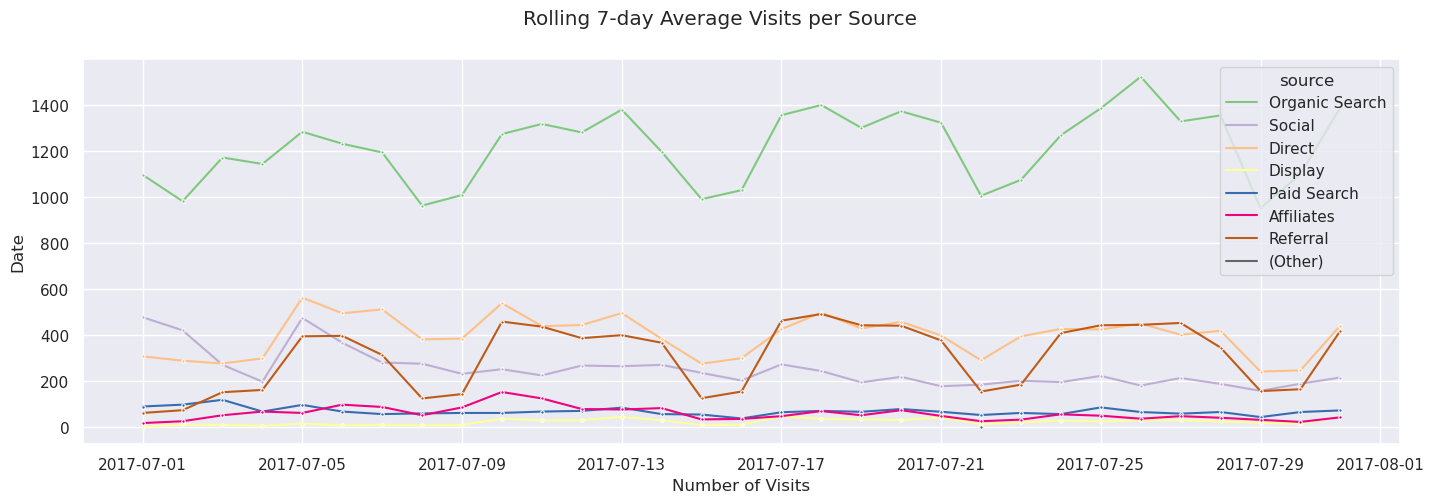

In [4]:
ts_query_2 = f"""
    WITH daily AS (
        SELECT
            PARSE_DATE('%Y%m%d', _TABLE_SUFFIX) AS date,
            channelGrouping AS source,
            COUNT(*) AS number_of_visits
        FROM {source}
        WHERE _TABLE_SUFFIX BETWEEN '20170701' AND '20170731'
        GROUP BY date, source
    )
    SELECT
        date,
        number_of_visits,
        source,
        AVG(number_of_visits) OVER (
            ORDER BY date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ) AS rolling_7d_avg
    FROM daily
    ORDER BY date
"""

ts_by_date = client.query_to_pandas_safe(ts_query_2)

fig, ax = plt.subplots(figsize=(17,5))

sns.lineplot(x='date', y='number_of_visits', hue='source', ax=ax, data=ts_by_date, marker='.', markersize=5)
ax.set_xlabel("Number of Visits")
ax.set_ylabel("Date")

plt.suptitle("Rolling 7-day Average Visits per Source")
plt.show()

# What are our Site's Top Pages?

Knowing these pages can show us which products are the most sought after by online customers, and this information can help the online store define its content marketing and SEO strategy. 

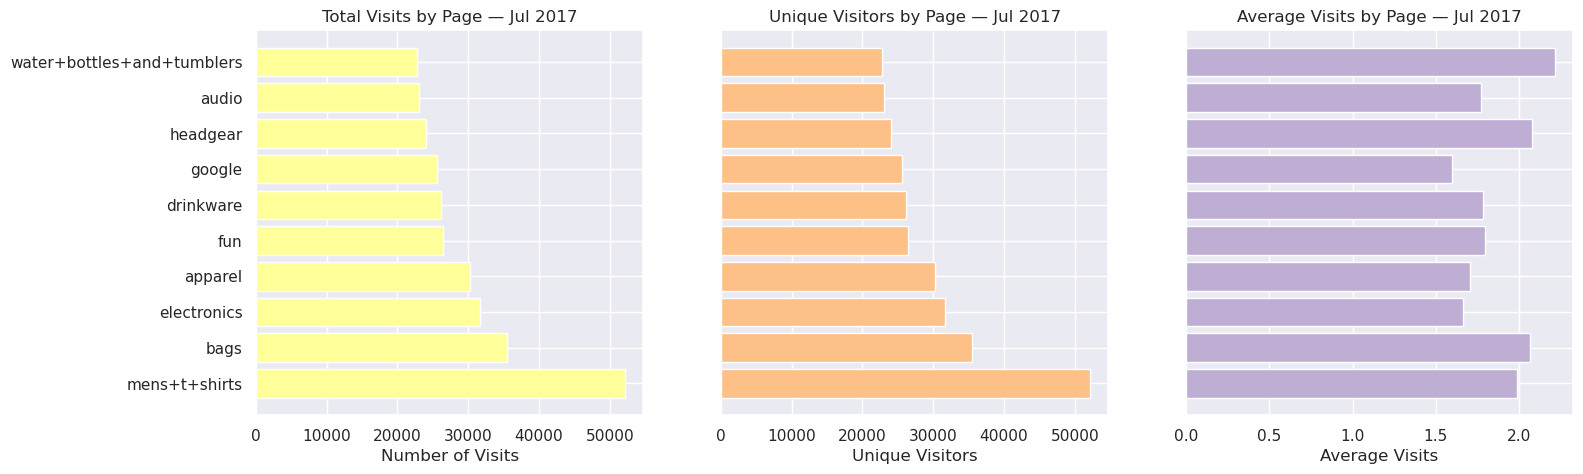

In [5]:
# Create query to select top pages
# Exclude obvious candidates like 'home' and html endings
pages_query = f"""
    WITH pages AS (
        SELECT
            REGEXP_EXTRACT(h.page.pagePath, r'[^/]+$') AS page,
            COUNT(h.page.pagePath) AS number_of_visits,
            COUNT(DISTINCT fullVisitorId) AS unique_visitors
        FROM {source}, UNNEST(hits) AS h
        WHERE _TABLE_SUFFIX BETWEEN '20170101' AND '20170731'
        GROUP BY page
    )
    SELECT page, number_of_visits, unique_visitors
    FROM pages
    WHERE page NOT LIKE '%html'
      AND page NOT IN ('home', 'quickview', 'youtube')
    ORDER BY number_of_visits DESC
    LIMIT 10
"""

top_pages = client.query_to_pandas_safe(pages_query)
top_pages['avg_visits'] = top_pages['number_of_visits'] / top_pages['unique_visitors']

# Create chart to show how channels compare
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(17, 5), sharey=True)

ax1.barh(top_pages['page'], top_pages['number_of_visits'], color=palette[3])
#ax1.invert_yaxis()
ax1.set_title("Total Visits by Page — Jul 2017")
ax1.set_xlabel("Number of Visits")

ax2.barh(top_pages['page'], top_pages['number_of_visits'], color=palette[2])
#ax2.invert_yaxis()
ax2.set_title("Unique Visitors by Page — Jul 2017")
ax2.set_xlabel("Unique Visitors")

ax3.barh(top_pages['page'], top_pages['avg_visits'], color=palette[1])
#ax2.invert_yaxis()
ax3.set_title("Average Visits by Page — Jul 2017")
ax3.set_xlabel("Average Visits")

plt.show()

Excluding the main site pages, when it comes to products, the most popular ones are: 
* Men's t-shirts
* Bags
* Electronics

# Where are our main customers located?
There is some information about users' location. While other demographic data would also be useful for building a customer profile, we are limited to world regions for now. Let's check how international our store is:

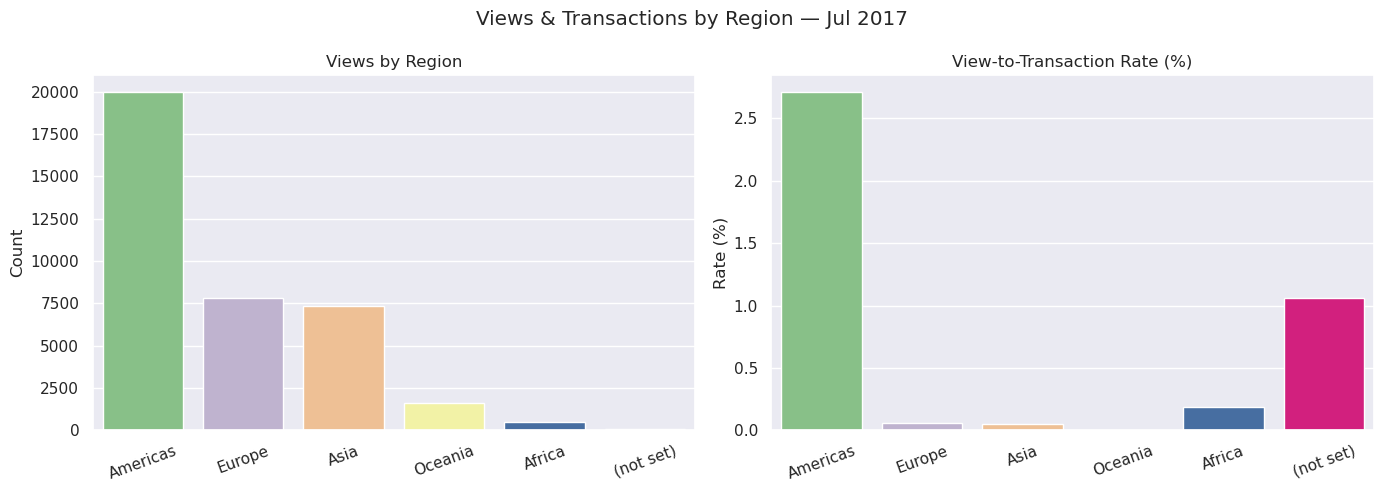

In [6]:
dem_query = f"""
    SELECT
        geoNetwork.continent AS region,
        COUNT(totals.pageviews) AS total_views,
        SUM(totals.transactions) AS total_transactions,
        ROUND(AVG(totals.pageviews), 2) AS avg_views,
        ROUND(AVG(totals.transactions), 2) AS avg_transactions,
        ROUND(SUM(totals.transactions) / COUNT(totals.pageviews) * 100, 2) AS views_to_transactions
    FROM {source}
    WHERE _TABLE_SUFFIX BETWEEN '20170701' AND '20170731'
    GROUP BY region
    ORDER BY total_views DESC
"""
dem_stats = client.query_to_pandas_safe(dem_query)

# Create a subplot with two pie charts
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Views & Transactions by Region — Jul 2017")

# Left: total views and transactions side by side
melted = dem_stats.melt(
    id_vars='region',
    value_vars=['total_views', 'total_transactions'],
    var_name='metric',
    value_name='value'
)

sns.barplot(data=melted, x='region', y='value', ax=ax1, errorbar=None)
ax1.set_title("Views by Region")
ax1.set_xlabel("")
ax1.set_ylabel("Count")
ax1.tick_params(axis='x', rotation=20)

# Right: views-to-transaction rate
sns.barplot(data=dem_stats, x='region', y='views_to_transactions', ax=ax2)
ax2.set_title("View-to-Transaction Rate (%)")
ax2.set_xlabel("")
ax2.set_ylabel("Rate (%)")
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

As we can see in our previous charts depicting views and transactions per region:

1. **International Audience:** Although North America is the dominant share of views and transactions, views from Europe and Asia are also significant, suggesting there is a demand or attention from these regions to the store.

2. **Imbalance between Views and Transactions:** This is likely to happen if a certain product or service is focused primarily on the US market, but depending on the product or service, expanding the audience might be a simple question of adding new payment methods or outsourcing delivery. 

In sum, depending on the objective or strategic goals of the store, it might be worth considering whether to expand business to attend other regions.

# What is the Daily Website Traffic? 

Let's have a look at the average visits and bounces. Doing this can help us better understand user behaviour, and might provide some insights about the best time for creating social media posts with content that might attract more users, such as promotions and discounts.

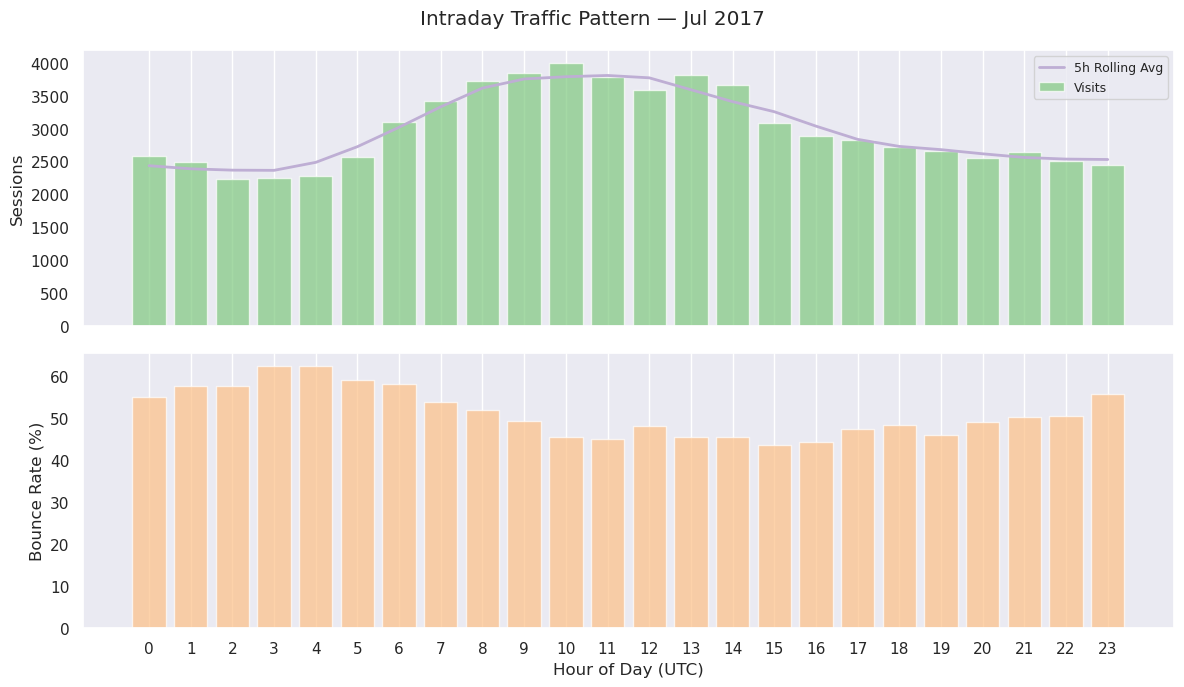

In [7]:
# We create CTEs to store metrics for further averaging
daily_trends_query = f"""
    WITH session_hours AS (
        SELECT
            MIN(h.hour)       AS hour,
            MAX(totals.bounces) AS bounced
        FROM {source}, UNNEST(hits) AS h
        WHERE _TABLE_SUFFIX BETWEEN '20170701' AND '20170731'
        GROUP BY fullVisitorId, visitId
    ),
    hourly AS (
        SELECT
            hour,
            COUNT(*) AS total_visits,
            SUM(bounced) AS total_bounces,
            ROUND(SAFE_DIVIDE(SUM(bounced), COUNT(*)) * 100, 2) AS bounce_rate
        FROM session_hours
        GROUP BY hour
    )
    SELECT
        hour,
        total_visits,
        total_bounces,
        bounce_rate,
        ROUND(AVG(total_visits) OVER (
            ORDER BY hour
            ROWS BETWEEN 2 PRECEDING AND 2 FOLLOWING
        ), 1) AS visits_rolling_avg
    FROM hourly
    ORDER BY hour
"""

daily_trends = client.query_to_pandas_safe(daily_trends_query)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Intraday Traffic Pattern — Jul 2017")

# Top: visits + rolling average
ax1.bar(daily_trends['hour'], daily_trends['total_visits'], alpha=0.7, label='Visits')
ax1.plot(daily_trends['hour'], daily_trends['visits_rolling_avg'], linewidth=2, label='5h Rolling Avg', color=palette[1])
ax1.set_ylabel("Sessions")
ax1.legend(fontsize=9)
ax1.grid(axis='y')

# Bottom: bounce rate
ax2.bar(daily_trends['hour'], daily_trends['bounce_rate'], alpha=0.7, color=palette[2])
ax2.set_ylabel("Bounce Rate (%)")
ax2.set_xlabel("Hour of Day (UTC)")
ax2.set_xticks(range(0, 24))
ax2.grid(axis='y')

plt.tight_layout()
plt.show()

# What are the Trends in Website Traffic? 

By analysing historical website traffic and sales data over a prolonged period, we can determine whether there are any identifiable patterns that repeat annually or at specific intervals. 

Below, we will group data by month and traffic source to see the trend over the first half of 2017.

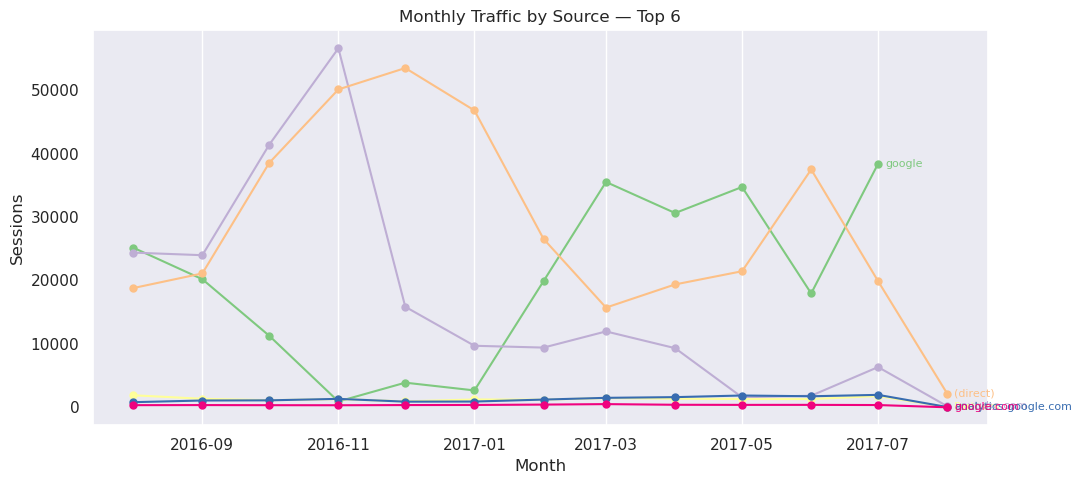

In [8]:

sources_query = f"""
    WITH top_sources AS (
        SELECT
            trafficSource.source AS traffic_source,
            COUNT(*) AS total_visits
        FROM {source}
        WHERE _TABLE_SUFFIX BETWEEN '20170101' AND '20170731'
        GROUP BY traffic_source
        ORDER BY total_visits DESC
        LIMIT 6
    )
    SELECT
        DATE_TRUNC(PARSE_DATE('%Y%m%d', _TABLE_SUFFIX), MONTH) AS month,
        trafficSource.source AS traffic_source,
        COUNT(*) AS total_visits
    FROM {source}
      WHERE trafficSource.source IN (SELECT traffic_source FROM top_sources)
    GROUP BY month, traffic_source
    ORDER BY month, total_visits DESC
"""

sources = client.query_to_pandas_safe(sources_query)

# Make sure month is interpreted as dt
sources['month'] = pd.to_datetime(sources['month'])

# Create line charts
fig, ax = plt.subplots(figsize=(11, 5))

unique_sources = sources['traffic_source'].unique()
for i, src in enumerate(unique_sources):
    df = sources[sources['traffic_source'] == src]
    ax.plot(df['month'], df['total_visits'], marker='o', label=src, color=palette[i], markersize=5)
    # label each line at its endpoint to avoid a cluttered legend
    ax.annotate(src, 
                xy=(df['month'].iloc[-1], 
                    df['total_visits'].iloc[-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8, 
                color=palette[i], 
                va='center')

ax.set_title("Monthly Traffic by Source — Top 6")
ax.set_xlabel("Month")
ax.set_ylabel("Sessions")
ax.legend().remove()
ax.grid(axis='y')

plt.tight_layout()
plt.show()

As we can see in our line chart depicting diverse traffic channels, a few salient observations come into focus:

1. **Growth in Organic Search:** The standout trend centers around the sustained growth in organic search traffic. This upward trajectory suggests an encouraging narrative of users organically discovering and engaging with the content. 

2. **Fluctuating Direct Traffic:** The direct traffic inflows chart shows fluctuations. Some periods register spikes, others see a dip. The unpredictability of this pattern merits a closer analysis. It would be useful to understand what contributes to the instability in this channel.

3. **Diminishing YouTube-Sourced Traffic:** Another insight emerges from the diminishing traffic originating from YouTube sources. This decline is a warning to check this channel in detail. Are there shifts in content?  Are we changing engagement strategies? Or maybe there are chnages in the YouTube algorithm that could be influencing this reduction? Addressing this issue would be good to foster growth again.

Reflecting on these findings, while organic search displays encouraging growth, it's worth considering the prospect of amplifying our focus on YouTube traffic. 

# Do More Views and Time Spent Equate to More Sales?

One thing that got me curious after looking at these stats was the information available on time spent per visit, as well as the number of pages viewed and the number of hits. Let's check below if these metrics correlate with more sales or not:

In [9]:
# Selecting all metrics where revenue is available
totals_query = f"""
    SELECT
        totals.pageviews AS pageviews,
        totals.timeOnSite AS time_on_site,
        totals.hits AS hits,
        totals.transactions AS transactions,
        totals.transactionRevenue AS revenue_usd
    FROM {source}
    WHERE totals.transactionRevenue IS NOT NULL
"""

totals = client.query_to_pandas_safe(totals_query)
totals.head()

,pageviews,time_on_site,hits,transactions,revenue_usd
0,4,96.0,4,1,31980000
1,8,484.0,8,1,27590000
2,10,243.0,11,1,12990000
3,10,1798.0,11,1,69500000
4,12,335.0,12,1,26620000


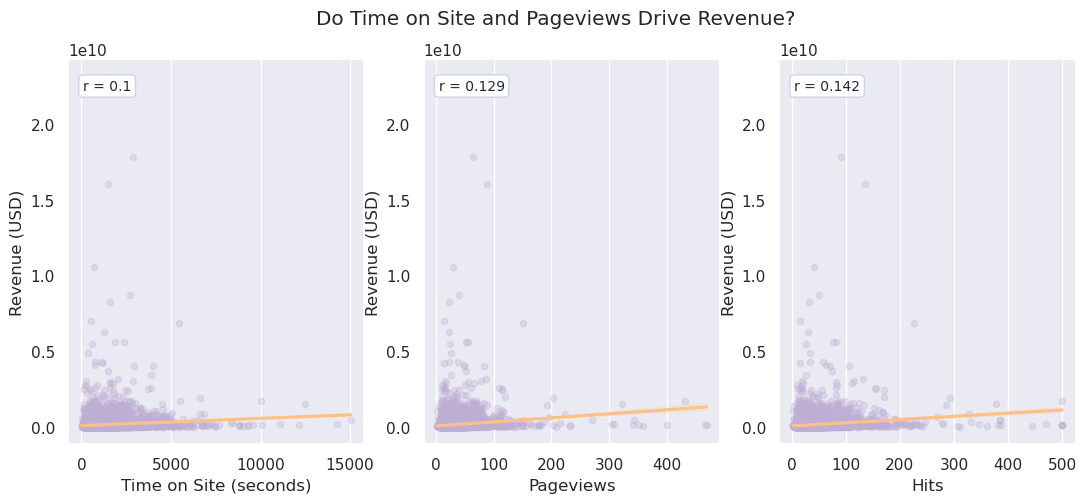

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

pairs = [
    ('time_on_site', 'Time on Site (seconds)'),
    ('pageviews',    'Pageviews'),
    ('hits',    'Hits'),
]

for ax, (col, label) in zip(axes, pairs):
    sns.regplot(
        data=totals,
        x=col,
        y='revenue_usd',
        ax=ax,
        scatter_kws={'alpha': 0.3, 's': 20, 'color': palette[1]},
        line_kws={'color':palette[2]}
    )
    corr = totals[col].corr(totals['revenue_usd']).round(3)
    ax.annotate(f"r = {corr}", xy=(0.05, 0.92), xycoords='axes fraction',
                fontsize=10, color='#1E293B',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#CBD5E1'))
    ax.set_xlabel(label)
    ax.set_ylabel("Revenue (USD)")
    ax.grid(axis='y')

fig.suptitle("Do Time on Site and Pageviews Drive Revenue?")
plt.show()

Results from the scatter plots above don't show any meaningful correlation between time spent on site or pageviews with the revenue. Likely, factors like product supply or specific discounts / marketing campaigns influence revenue a lot more than these specific signals.

# Areas for Improvement

We've looked at the average weekly trends, source channels, as well as built a few regression models to check correlations with transaction revenue. This information can help improve the website's search engine optimization (SEO), as well as shift focus to products that drive more revenue. 

We also saw a growing interest from people around the world, although not yet translated into sales - this might be an opportunity for growth.

With this knowledge, it's possible to adapt the company's approach to better fit customer expectations and expand strategically, engage more with their audience, and maintain a strong presence in the market.